# 모델 + 데이터 분석
https://www.data.go.kr/data/15083033/fileData.do

In [ ]:
from glob import glob

file_path = r'C:\SKN_29th\git_src\머신러닝\09. 실습\data\*.csv'
files = glob(file_path)
files = files[4:]
files

['C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_광주_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_대구_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_대전_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_부산_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_서울_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_세종_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_울산_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_인천_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_전남_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_전북_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_제주_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\data\\소상공인시장진흥공단_상가(상권)정보_충남_202512.csv',
 'C:\\SKN_29th\\git_src\\머신러닝\\9. 실습\\da

In [14]:
import pandas as pd
df = pd.read_csv(files[0])
# 불필요한 컬럼제거 - 의미가 중복된 데이터는 제거하는 것이 좋다.

In [15]:
new_cols = ['상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', 
            '시도명', '시군구명', '행정동명', '법정동명', '도로명주소', '위도', '경도']
df[new_cols].head()

,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,법정동명,도로명주소,위도,경도
0,정비대장,NaN,수리·개인,자동차 수리·세차,자동차 정비소,광주광역시,광산구,신가동,신가동,광주광역시 광산구 목련로 371,35.181646,126.832049
1,모다,NaN,소매,섬유·의복·신발 소매,신발 소매업,광주광역시,서구,화정4동,화정동,광주광역시 서구 월드컵4강로 75,35.143560,126.873903
2,큰소리내는사람들,NaN,교육,기타 교육,레크리에이션 교육기관,광주광역시,서구,상무2동,쌍촌동,광주광역시 서구 운천로113번길 23,35.143965,126.856696
3,오땡큐블루커트,NaN,수리·개인,이용·미용,미용실,광주광역시,서구,금호1동,금호동,광주광역시 서구 금화로149번길 27,35.134426,126.862473
4,피드마케팅,NaN,과학·기술,광고,광고 대행업,광주광역시,광산구,비아동,비아동,광주광역시 광산구 비아로127번길 42,35.224071,126.818385


In [16]:
# 결측치 확인
shop = df[new_cols]
shop.isnull().sum()

상호명             0
지점명         68047
상권업종대분류명        0
상권업종중분류명        0
상권업종소분류명        0
시도명             0
시군구명            0
행정동명            0
법정동명            0
도로명주소           0
위도              0
경도              0
dtype: int64

In [ ]:
# %pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [17]:
# 한글설정
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

<Axes: >

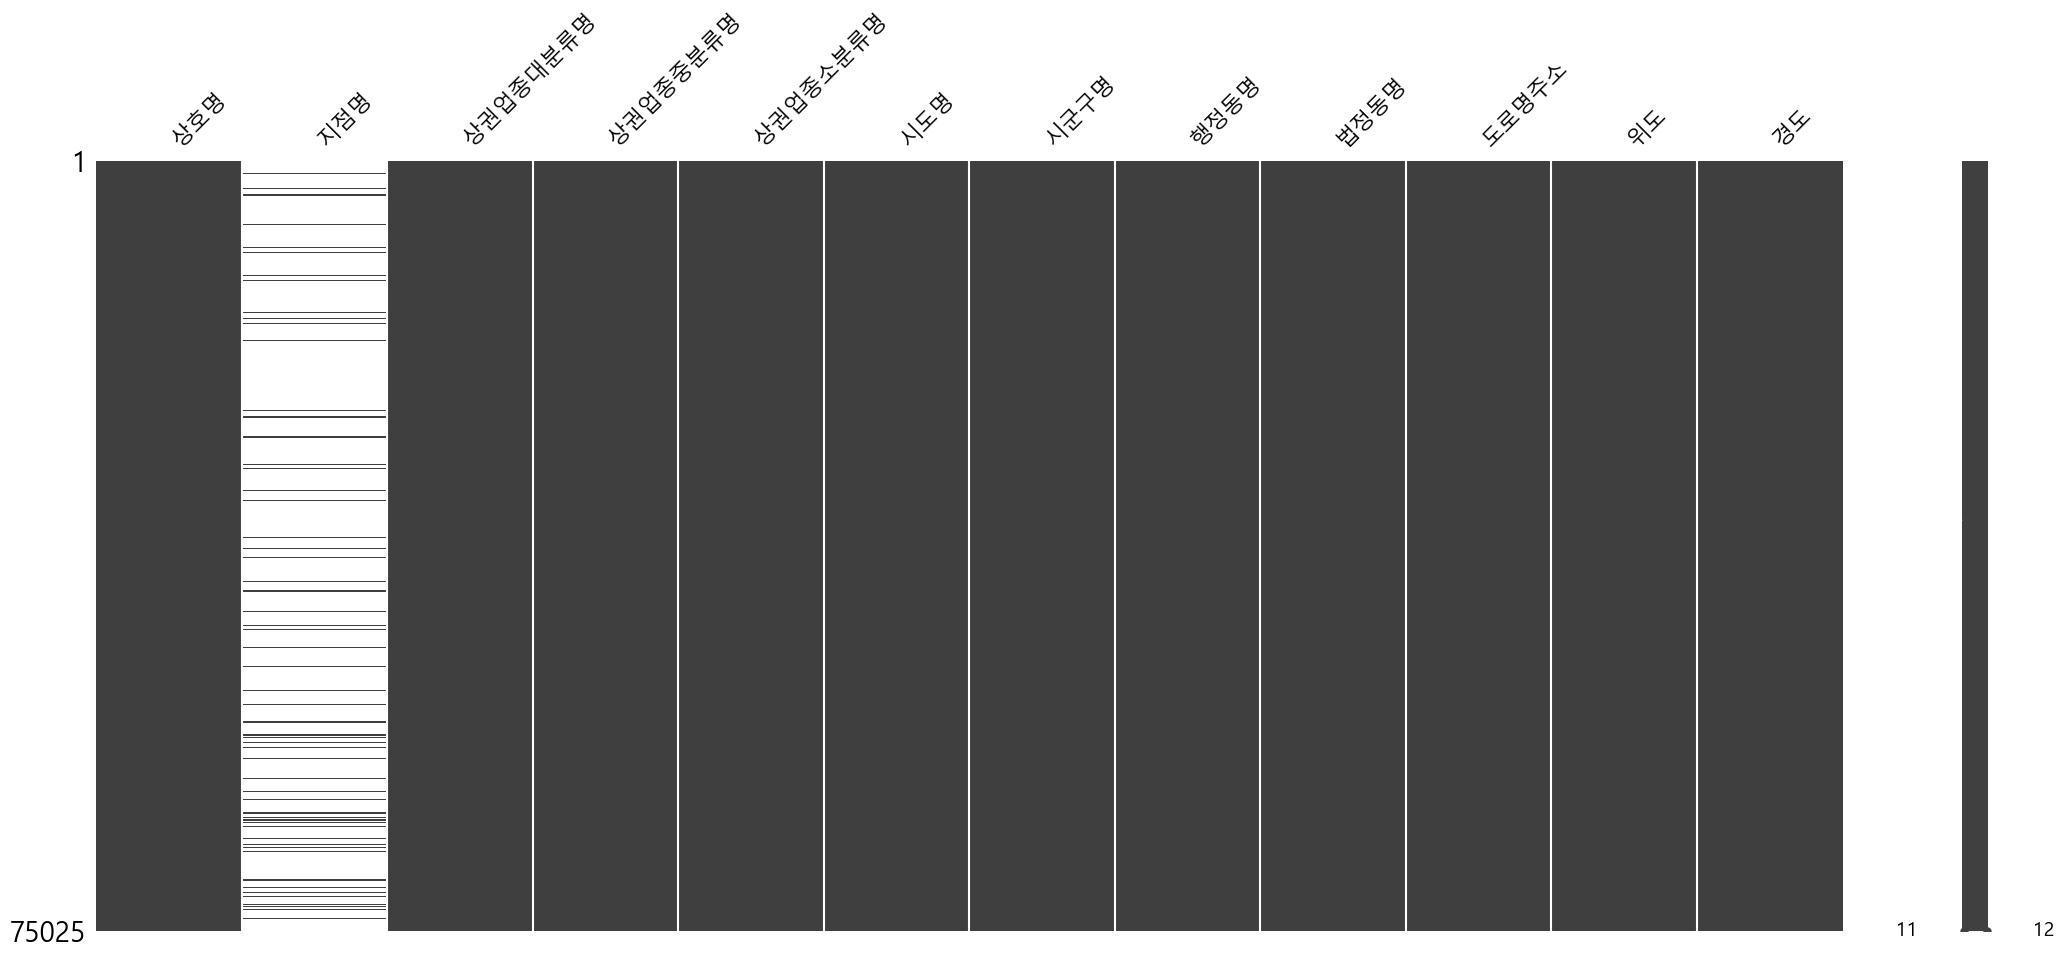

In [18]:
# 결측치 시각적으로 보기
import missingno as msno
msno.matrix(shop)

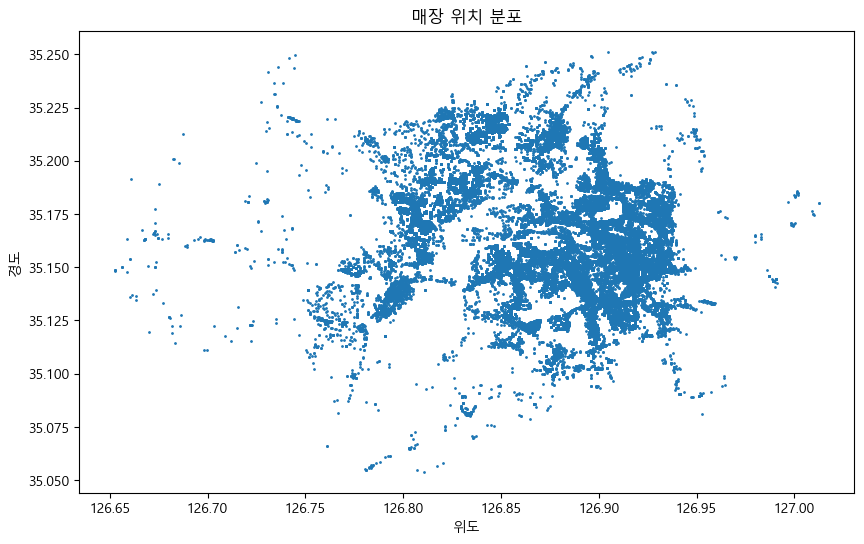

In [20]:
fig,ax = plt.subplots(figsize=(10, 6))
plt.plot(shop['경도'],shop['위도'], 'o', markersize=1)
plt.xlabel('위도')
plt.ylabel('경도')
plt.title('매장 위치 분포')
plt.show()

<Axes: xlabel='경도', ylabel='위도'>

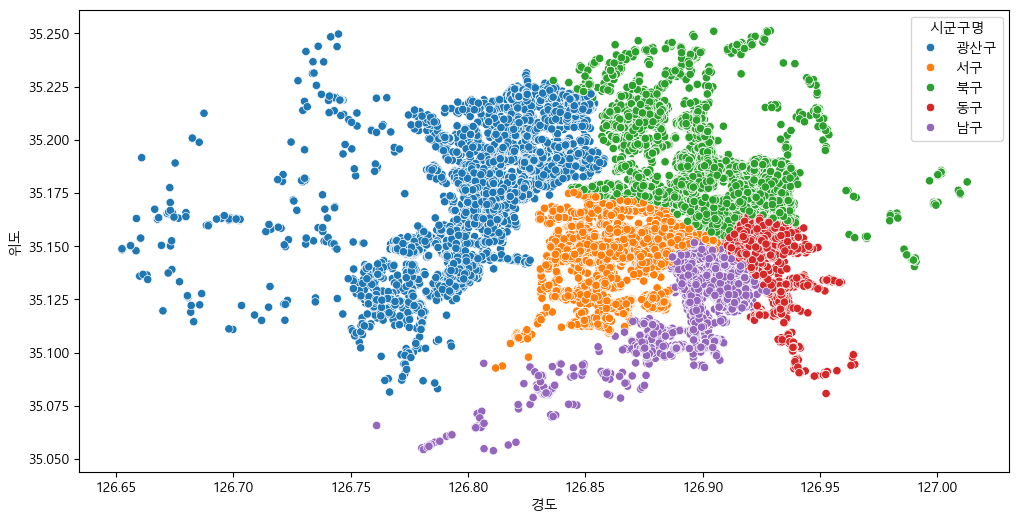

In [21]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=shop,x='경도',y='위도',hue='시군구명',ax=ax)

<Axes: xlabel='경도', ylabel='위도'>

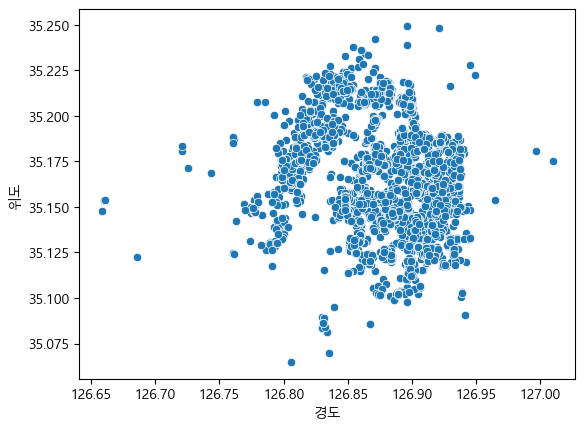

In [22]:
# 상권업종 대분류명이  교육과 관련된 정보
import numpy as np
edu_shop = shop[shop['상권업종대분류명']=='교육']
sns.scatterplot(edu_shop,x='경도',y='위도')

In [23]:
# 반경 200m 내 점포수
# 동일 업종수
# 경쟁 강도(같은 업종 density)

# step1 결측치 제거
# step2 공간 Feature 생성  KDTree
# step3 모델 정의(분류 회귀)
# step4 학습
from sklearn.neighbors import BallTree
coors = np.radians(shop[['위도','경도']].values)  # 각도를 degree ~~도   -> 라디안 radian으로 변환
tree = BallTree(coors,metric='haversine')  # 단위가 radian

# 500m반경
radius = 0.5 / 6371
counts = tree.query_radius(coors,r=radius,count_only=True)
shop.loc[:,'store_density_500m']  = counts

In [25]:
# 음식점 기준
target_category = '음식'
food_mask = (shop['상권업종대분류명'] == target_category)

food_coors = np.radians(shop.loc[food_mask,['위도','경도']].values)
food_tree = BallTree(food_coors,metric='haversine') 

# 전체 좌표 기준으로 음식점 수 계산
food_counts = food_tree.query_radius(coors, r=radius, count_only=True)
shop.loc[:,'fodd_density_500'] = food_counts

In [26]:
# 경쟁강도
shop.loc[:,'competition_ratio'] = (shop['fodd_density_500'] / shop['store_density_500m'])
# 0에 가까울수록 경쟁적음  1에 가까울수록 경쟁이 심함

In [27]:
indices = tree.query_radius(coors, r=radius)
diversity = [len(shop.iloc[idx_list]['상권업종중분류명'].unique()) for idx_list in indices]

In [28]:
shop['category_deiversity_500m'] = diversity

In [29]:
shop.loc[:,'위도':].head(2)

,위도,경도,store_density_500m,fodd_density_500,competition_ratio,category_deiversity_500m
0,35.181646,126.832049,334,75,0.224551,55
1,35.143560,126.873903,765,236,0.308497,55


In [30]:
X = shop.loc[:,'위도':]
X['score'] = (
    0.4*X['store_density_500m']  # 전체상권 활성도
    -0.3*X['competition_ratio']  # 경쟁강도(패널티)
    +0.3*X['category_deiversity_500m']  #상권의 다양성
)
y = X['score']

In [31]:
# 주변 점포수 많음 - >사람 많음 -> 좋은 입지
X.head()

,위도,경도,store_density_500m,fodd_density_500,competition_ratio,category_deiversity_500m,score
0,35.181646,126.832049,334,75,0.224551,55,150.032635
1,35.143560,126.873903,765,236,0.308497,55,322.407451
2,35.143965,126.856696,656,206,0.314024,61,280.605793
3,35.134426,126.862473,565,217,0.384071,49,240.584779
4,35.224071,126.818385,135,36,0.266667,35,64.420000


In [32]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(X,y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1603
[LightGBM] [Info] Number of data points in the train set: 75025, number of used features: 7
[LightGBM] [Info] Start training from score 308.684565


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
# 기존 매장위치가 아니라 새로운 후보 위치를 만들어서 평가
# 새로 어디에 창업할지에 대한 정보가 없음
# 가상의 후보 위치 생성
lat_min, lat_max =  shop['위도'].min(), shop['위도'].max()
lon_min, lon_max = shop['경도'].min(), shop['경도'].max()